<a href="https://colab.research.google.com/github/mfernandezzz/Pruebas_Tecnicas/blob/main/pruebaTecnicaAmazon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import pandas as pd
import numpy as np

In [51]:
df = pd.read_csv('/content/amazon_reviews_small.csv')
pd.set_option('display.max_columns', None)
df.head(4)

,Unnamed: 0.2,level_0,Unnamed: 0.1,index,Unnamed: 0,ASIN,Review_Title,Review_Content,Review_Stars,Review_Date,Reviewer_Name,Verified_Purchase,Helpful_Votes,Review_URL,Product Name,Brand,Rating,Product Description,Category,Cleaned_Review_Content,Cleaned_Review,Predicted_Sentiment_DistilBERT,Predicted_Sentiment_Label_DistilBERT,Predicted_Sentiment_RoBERTa,Predicted_Sentiment_Label_RoBERTa
0,0,0,0,0,0,B0CMDJ844V,Super Fast Cell Phone with Great Camera,⭐️⭐️⭐️⭐️⭐️\n\nThe SAMSUNG Galaxy S24 Ultra is ...,5.0,"Reviewed in the United States on August 15, 2024",MZ,Verified Purchase,36,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,the samsung galaxy s ultra is an absolute powe...,the samsung galaxy s ultra is an absolute powe...,1,Positive,2,1
1,1,2,2,4,4,B0CMDJ844V,Big and beautiful,Phone is big and beautiful. OS is super quick....,5.0,"Reviewed in the United States on August 30, 2024",Adrian,Verified Purchase,8,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,phone is big and beautiful os is super quick c...,phone is big and beautiful os is super quick c...,1,Positive,2,1
2,2,4,4,8,8,B0CMDJ844V,Refined to a very powerful practical tool,I had the S23 ultra but ran it over by acciden...,4.0,"Reviewed in the United States on September 6, ...",RMI,Verified Purchase,2,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,i had the s ultra but ran it over by accident ...,i had the s ultra but ran it over by accident ...,1,Positive,1,2
3,3,6,6,12,12,B0CMDJ844V,"Bought it ""Used"" got lucky, came with box look...",I've only owned every version of the Note seri...,4.0,"Reviewed in the United States on April 9, 2024",MZ,Verified Purchase,0,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,ive only owned every version of the note serie...,ive only owned every version of the note serie...,0,Negative,1,2


In [52]:
df.shape

(24308, 25)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24308 entries, 0 to 24307
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Unnamed: 0.2                          24308 non-null  int64  
 1   level_0                               24308 non-null  int64  
 2   Unnamed: 0.1                          24308 non-null  int64  
 3   index                                 24308 non-null  int64  
 4   Unnamed: 0                            24308 non-null  int64  
 5   ASIN                                  24308 non-null  object 
 6   Review_Title                          24303 non-null  object 
 7   Review_Content                        24308 non-null  object 
 8   Review_Stars                          24308 non-null  float64
 9   Review_Date                           24308 non-null  object 
 10  Reviewer_Name                         23059 non-null  object 
 11  Verified_Purcha

In [54]:
df.columns

Index(['Unnamed: 0.2', 'level_0', 'Unnamed: 0.1', 'index', 'Unnamed: 0',
       'ASIN', 'Review_Title', 'Review_Content', 'Review_Stars', 'Review_Date',
       'Reviewer_Name', 'Verified_Purchase', 'Helpful_Votes', 'Review_URL',
       'Product Name', 'Brand', 'Rating', 'Product Description', 'Category',
       'Cleaned_Review_Content', 'Cleaned_Review',
       'Predicted_Sentiment_DistilBERT',
       'Predicted_Sentiment_Label_DistilBERT', 'Predicted_Sentiment_RoBERTa',
       'Predicted_Sentiment_Label_RoBERTa'],
      dtype='object')

In [55]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_')
)
df.columns

Index(['unnamed:_0.2', 'level_0', 'unnamed:_0.1', 'index', 'unnamed:_0',
       'asin', 'review_title', 'review_content', 'review_stars', 'review_date',
       'reviewer_name', 'verified_purchase', 'helpful_votes', 'review_url',
       'product_name', 'brand', 'rating', 'product_description', 'category',
       'cleaned_review_content', 'cleaned_review',
       'predicted_sentiment_distilbert',
       'predicted_sentiment_label_distilbert', 'predicted_sentiment_roberta',
       'predicted_sentiment_label_roberta'],
      dtype='object')

In [56]:
dupplex = df.duplicated().sum()
dupplex

np.int64(0)

In [57]:
columns_nulls_count = df.isnull().sum()
columns_nulls_count[columns_nulls_count > 0].sort_values(ascending=False)

,0
product_description,9911
brand,9569
product_name,9456
rating,9433
reviewer_name,1249
verified_purchase,156
review_title,5


In [58]:
columns_nulls = df.isnull().mean()*100
columns_nulls[columns_nulls > 0].sort_values(ascending=False)

,0
product_description,40.772585
brand,39.365641
product_name,38.900773
rating,38.806154
reviewer_name,5.138226
verified_purchase,0.641764
review_title,0.020569


In [59]:
cat_cols = ['product_description', 'brand', 'product_name', 'reviewer_name', 'review_title']
df[cat_cols] = df[cat_cols].fillna('Unknown')

In [60]:
df['rating'].unique()

array(['4.5 out of 5 stars', '3.8 out of 5 stars', '3.9 out of 5 stars',
       '4.1 out of 5 stars', '4.2 out of 5 stars', '4.0 out of 5 stars',
       '4.4 out of 5 stars', '4.3 out of 5 stars', '3.7 out of 5 stars',
       '4.7 out of 5 stars', '4.6 out of 5 stars', '3.6 out of 5 stars',
       '5.0 out of 5 stars', '3.5 out of 5 stars', nan,
       '2.8 out of 5 stars', '3.4 out of 5 stars', '4.9 out of 5 stars',
       '4.8 out of 5 stars', '2.9 out of 5 stars', '3.3 out of 5 stars'],
      dtype=object)

In [61]:
df['rating'] = df['rating'].fillna('no rating')

In [63]:
df['rating'].value_counts().head()

,count
rating,
no rating,9433
4.3 out of 5 stars,2914
4.2 out of 5 stars,2593
4.4 out of 5 stars,2192
4.0 out of 5 stars,1675


In [32]:
df['verified_purchase'].unique()

array(['Verified Purchase', nan], dtype=object)

In [64]:
df['verified_purchase'] = df['verified_purchase'].fillna('Unverified Purchase')

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24308 entries, 0 to 24307
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   unnamed:_0.2                          24308 non-null  int64  
 1   level_0                               24308 non-null  int64  
 2   unnamed:_0.1                          24308 non-null  int64  
 3   index                                 24308 non-null  int64  
 4   unnamed:_0                            24308 non-null  int64  
 5   asin                                  24308 non-null  object 
 6   review_title                          24308 non-null  object 
 7   review_content                        24308 non-null  object 
 8   review_stars                          24308 non-null  float64
 9   review_date                           24308 non-null  object 
 10  reviewer_name                         24308 non-null  object 
 11  verified_purcha

**¿Cual ha sido la review de Amazon mas util?**

Obtener el valor maximo de la columna 'helpful_votes'

In [66]:
max_helpful_votes = df['helpful_votes'].max()
max_helpful_votes

921

Localizar la review mas util

In [67]:
helpful_review = df.loc[df['helpful_votes'] == max_helpful_votes]
helpful_review

,unnamed:_0.2,level_0,unnamed:_0.1,index,unnamed:_0,asin,review_title,review_content,review_stars,review_date,reviewer_name,verified_purchase,helpful_votes,review_url,product_name,brand,rating,product_description,category,cleaned_review_content,cleaned_review,predicted_sentiment_distilbert,predicted_sentiment_label_distilbert,predicted_sentiment_roberta,predicted_sentiment_label_roberta
6141,6141,12282,12282,24564,24564,B01N1P0KCN,Wouldn’t recommend,"Everything is working as it should, Love the p...",1.0,"Reviewed in the United States on January 27, 2022",LMealy,Verified Purchase,921,https://www.amazon.com/product-reviews/B01N1P0...,Unknown,Unknown,no rating,Unknown,Mobile,everything is working as it should love the phone,everything is working as it should love the phone,1,Positive,2,1


In [68]:
helpful_review[['review_title', 'review_stars', 'reviewer_name', 'verified_purchase', 'product_name', 'brand', 'rating', 'product_description', 'category']]

,review_title,review_stars,reviewer_name,verified_purchase,product_name,brand,rating,product_description,category
6141,Wouldn’t recommend,1.0,LMealy,Verified Purchase,Unknown,Unknown,no rating,Unknown,Mobile


In [69]:
helpful_review[['cleaned_review']]

,cleaned_review
6141,everything is working as it should love the phone


Otra solucion:

In [70]:
# idmax() obtiene el registro del valor maximo asociado a la columna
most_help_review = df.loc[[df['helpful_votes'].idxmax()]]
most_help_review

,unnamed:_0.2,level_0,unnamed:_0.1,index,unnamed:_0,asin,review_title,review_content,review_stars,review_date,reviewer_name,verified_purchase,helpful_votes,review_url,product_name,brand,rating,product_description,category,cleaned_review_content,cleaned_review,predicted_sentiment_distilbert,predicted_sentiment_label_distilbert,predicted_sentiment_roberta,predicted_sentiment_label_roberta
6141,6141,12282,12282,24564,24564,B01N1P0KCN,Wouldn’t recommend,"Everything is working as it should, Love the p...",1.0,"Reviewed in the United States on January 27, 2022",LMealy,Verified Purchase,921,https://www.amazon.com/product-reviews/B01N1P0...,Unknown,Unknown,no rating,Unknown,Mobile,everything is working as it should love the phone,everything is working as it should love the phone,1,Positive,2,1


**Obtener la review mas util para los productos de la categoria Laptop**

In [72]:
df['category'].value_counts()

,count
category,
Mobile,15766
Earphones,3487
TV,3436
Laptop,1619


In [73]:
df_laptop = df.loc[df['category'] == 'Laptop']
df_laptop.head()

,unnamed:_0.2,level_0,unnamed:_0.1,index,unnamed:_0,asin,review_title,review_content,review_stars,review_date,reviewer_name,verified_purchase,helpful_votes,review_url,product_name,brand,rating,product_description,category,cleaned_review_content,cleaned_review,predicted_sentiment_distilbert,predicted_sentiment_label_distilbert,predicted_sentiment_roberta,predicted_sentiment_label_roberta
19253,19253,38506,38506,77012,77012,B0947BJ67M,Excellent for price.,Thin and well finished. Typical excellent HP q...,5.0,"Reviewed in the United States on September 16,...",John S. Presnick,Verified Purchase,0,https://www.amazon.com/product-reviews/B0947BJ...,"HP 14 Laptop, Intel Celeron N4020, 4 GB RAM, 6...",Visit the HP Store,4.5 out of 5 stars,About this itemREADY FOR ANYWHERE – With its t...,Laptop,thin and well finished typical excellent hp qu...,thin and well finished typical excellent hp qu...,0,Negative,2,1
19254,19254,38508,38508,77016,77016,B0947BJ67M,"Works great, great price",I see posts of negative reviews about yhe good...,5.0,"Reviewed in the United States on August 22, 2024",Unknown,Verified Purchase,5,https://www.amazon.com/product-reviews/B0947BJ...,"HP 14 Laptop, Intel Celeron N4020, 4 GB RAM, 6...",Visit the HP Store,4.5 out of 5 stars,About this itemREADY FOR ANYWHERE – With its t...,Laptop,i see posts of negative reviews about yhe good...,i see posts of negative reviews about yhe good...,1,Positive,2,1
19255,19255,38510,38510,77020,77020,B0947BJ67M,"HP 14 Laptop: Great for a notebook under $200,...",The HP 14 is a great choice for those looking ...,4.0,"Reviewed in the United States on July 7, 2024",Brit,Verified Purchase,0,https://www.amazon.com/product-reviews/B0947BJ...,"HP 14 Laptop, Intel Celeron N4020, 4 GB RAM, 6...",Visit the HP Store,4.5 out of 5 stars,About this itemREADY FOR ANYWHERE – With its t...,Laptop,the hp is a great choice for those looking for...,the hp is a great choice for those looking for...,0,Negative,2,1
19256,19256,38512,38512,77024,77024,B0947BJ67M,Works fine,I use it for internet to study and watch lectu...,5.0,"Reviewed in the United States on September 4, ...",Allan R,Verified Purchase,2,https://www.amazon.com/product-reviews/B0947BJ...,"HP 14 Laptop, Intel Celeron N4020, 4 GB RAM, 6...",Visit the HP Store,4.5 out of 5 stars,About this itemREADY FOR ANYWHERE – With its t...,Laptop,i use it for internet to study and watch lectu...,i use it for internet to study and watch lectu...,0,Negative,2,1
19257,19257,38514,38514,77028,77028,B0947BJ67M,Go 14,Works slow but good enough to access all my ac...,4.0,"Reviewed in the United States on July 20, 2024",Jenny Avril,Verified Purchase,15,https://www.amazon.com/product-reviews/B0947BJ...,"HP 14 Laptop, Intel Celeron N4020, 4 GB RAM, 6...",Visit the HP Store,4.5 out of 5 stars,About this itemREADY FOR ANYWHERE – With its t...,Laptop,works slow but good enough to access all my ac...,works slow but good enough to access all my ac...,1,Positive,2,1


In [74]:
# se localiza en base al indice que tiene asociado el valor de votos utiles mas alto
helpful_review_laptop = df_laptop.loc[[df_laptop['helpful_votes'].idxmax()]]
helpful_review_laptop[['review_title', 'review_stars', 'reviewer_name', 'verified_purchase', 'helpful_votes', 'product_name', 'rating', 'cleaned_review']]

,review_title,review_stars,reviewer_name,verified_purchase,helpful_votes,product_name,rating,cleaned_review
19669,Soooo gooddd!!,5.0,krozz96,Verified Purchase,649,"HP Newest 14"" HD Laptop, Windows 11, Intel Cel...",4.5 out of 5 stars,its good useful fast


**¿Cual es la review de Amazon mas comun?**

In [75]:
df.columns

Index(['unnamed:_0.2', 'level_0', 'unnamed:_0.1', 'index', 'unnamed:_0',
       'asin', 'review_title', 'review_content', 'review_stars', 'review_date',
       'reviewer_name', 'verified_purchase', 'helpful_votes', 'review_url',
       'product_name', 'brand', 'rating', 'product_description', 'category',
       'cleaned_review_content', 'cleaned_review',
       'predicted_sentiment_distilbert',
       'predicted_sentiment_label_distilbert', 'predicted_sentiment_roberta',
       'predicted_sentiment_label_roberta'],
      dtype='object')

Si se toma los datos contenidos en la columna 'Review_Stars'

In [80]:
df['review_stars'].value_counts()

,count
review_stars,
5.0,12764
4.0,5091
1.0,2747
3.0,2377
2.0,1329


In [81]:
reviews_rate = pd.DataFrame(df['review_stars'].value_counts()).reset_index()
reviews_rate

,review_stars,count
0,5.0,12764
1,4.0,5091
2,1.0,2747
3,3.0,2377
4,2.0,1329


In [82]:
reviews_rate['%'] = round(reviews_rate['count'] / reviews_rate['count'].sum() * 100, 2)
reviews_rate

,review_stars,count,%
0,5.0,12764,52.51
1,4.0,5091,20.94
2,1.0,2747,11.30
3,3.0,2377,9.78
4,2.0,1329,5.47


Si se toma en cuenta los datos contenidos en la columna 'Rating'

In [85]:
df_rating = pd.DataFrame(df['rating'].value_counts()).reset_index()
df_rating.head()

,rating,count
0,no rating,9433
1,4.3 out of 5 stars,2914
2,4.2 out of 5 stars,2593
3,4.4 out of 5 stars,2192
4,4.0 out of 5 stars,1675


In [86]:
df_rating['%'] = round(df_rating['count'] / df_rating['count'].sum() * 100, 2)
df_rating.head() # sort_index()

,rating,count,%
0,no rating,9433,38.81
1,4.3 out of 5 stars,2914,11.99
2,4.2 out of 5 stars,2593,10.67
3,4.4 out of 5 stars,2192,9.02
4,4.0 out of 5 stars,1675,6.89


**¿Que porcentaje de reviews son positivas y negativas?**

In [87]:
df.head()

,unnamed:_0.2,level_0,unnamed:_0.1,index,unnamed:_0,asin,review_title,review_content,review_stars,review_date,reviewer_name,verified_purchase,helpful_votes,review_url,product_name,brand,rating,product_description,category,cleaned_review_content,cleaned_review,predicted_sentiment_distilbert,predicted_sentiment_label_distilbert,predicted_sentiment_roberta,predicted_sentiment_label_roberta
0,0,0,0,0,0,B0CMDJ844V,Super Fast Cell Phone with Great Camera,⭐️⭐️⭐️⭐️⭐️\n\nThe SAMSUNG Galaxy S24 Ultra is ...,5.0,"Reviewed in the United States on August 15, 2024",MZ,Verified Purchase,36,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,the samsung galaxy s ultra is an absolute powe...,the samsung galaxy s ultra is an absolute powe...,1,Positive,2,1
1,1,2,2,4,4,B0CMDJ844V,Big and beautiful,Phone is big and beautiful. OS is super quick....,5.0,"Reviewed in the United States on August 30, 2024",Adrian,Verified Purchase,8,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,phone is big and beautiful os is super quick c...,phone is big and beautiful os is super quick c...,1,Positive,2,1
2,2,4,4,8,8,B0CMDJ844V,Refined to a very powerful practical tool,I had the S23 ultra but ran it over by acciden...,4.0,"Reviewed in the United States on September 6, ...",RMI,Verified Purchase,2,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,i had the s ultra but ran it over by accident ...,i had the s ultra but ran it over by accident ...,1,Positive,1,2
3,3,6,6,12,12,B0CMDJ844V,"Bought it ""Used"" got lucky, came with box look...",I've only owned every version of the Note seri...,4.0,"Reviewed in the United States on April 9, 2024",MZ,Verified Purchase,0,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,ive only owned every version of the note serie...,ive only owned every version of the note serie...,0,Negative,1,2
4,4,8,8,16,16,B0CMDJ844V,"Big, beautiful screen and super fast CPU",Samsung Galaxy S24 Ultra 512gb unlocked versio...,5.0,"Reviewed in the United States on August 30, 2024",Alex Beyer,Verified Purchase,5,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,samsung galaxy s ultra gb unlocked version wha...,samsung galaxy s ultra gb unlocked version wha...,1,Positive,2,1


In [88]:
df.columns

Index(['unnamed:_0.2', 'level_0', 'unnamed:_0.1', 'index', 'unnamed:_0',
       'asin', 'review_title', 'review_content', 'review_stars', 'review_date',
       'reviewer_name', 'verified_purchase', 'helpful_votes', 'review_url',
       'product_name', 'brand', 'rating', 'product_description', 'category',
       'cleaned_review_content', 'cleaned_review',
       'predicted_sentiment_distilbert',
       'predicted_sentiment_label_distilbert', 'predicted_sentiment_roberta',
       'predicted_sentiment_label_roberta'],
      dtype='object')

In [93]:
df_review_stars = pd.DataFrame(df['review_stars'].value_counts())
df_review_stars['%'] = round(df_review_stars['count'] / df_review_stars['count'].sum() * 100, 2)
df_review_stars

,count,%
review_stars,,
5.0,12764,52.51
4.0,5091,20.94
1.0,2747,11.30
3.0,2377,9.78
2.0,1329,5.47


In [94]:
positive_reviews = df_review_stars.loc[5] + df_review_stars.loc[4]
positive_reviews

,0
count,17855.00
%,73.45


In [95]:
negative_reviews = df_review_stars.loc[3] + df_review_stars.loc[2] + df_review_stars.loc[1]
negative_reviews

,0
count,6453.00
%,26.55


In [96]:
df_positives_negatives = pd.DataFrame({
    'positive_reviews': positive_reviews,
    'negative_reviews': negative_reviews,
}, columns=['positive_reviews', 'negative_reviews'])
df_positives_negatives

,positive_reviews,negative_reviews
count,17855.00,6453.00
%,73.45,26.55


**¿Existe relacion entre la longitud de la review y sus votos utiles?**

Nueva columna que almacena el largo de las reviews

In [97]:
df['review_length'] = df['review_content'].str.len()
#df['Review_Length'] = df['Review_Length'].astype(int).str.len()
df.head()

,unnamed:_0.2,level_0,unnamed:_0.1,index,unnamed:_0,asin,review_title,review_content,review_stars,review_date,reviewer_name,verified_purchase,helpful_votes,review_url,product_name,brand,rating,product_description,category,cleaned_review_content,cleaned_review,predicted_sentiment_distilbert,predicted_sentiment_label_distilbert,predicted_sentiment_roberta,predicted_sentiment_label_roberta,review_length
0,0,0,0,0,0,B0CMDJ844V,Super Fast Cell Phone with Great Camera,⭐️⭐️⭐️⭐️⭐️\n\nThe SAMSUNG Galaxy S24 Ultra is ...,5.0,"Reviewed in the United States on August 15, 2024",MZ,Verified Purchase,36,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,the samsung galaxy s ultra is an absolute powe...,the samsung galaxy s ultra is an absolute powe...,1,Positive,2,1,1451
1,1,2,2,4,4,B0CMDJ844V,Big and beautiful,Phone is big and beautiful. OS is super quick....,5.0,"Reviewed in the United States on August 30, 2024",Adrian,Verified Purchase,8,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,phone is big and beautiful os is super quick c...,phone is big and beautiful os is super quick c...,1,Positive,2,1,557
2,2,4,4,8,8,B0CMDJ844V,Refined to a very powerful practical tool,I had the S23 ultra but ran it over by acciden...,4.0,"Reviewed in the United States on September 6, ...",RMI,Verified Purchase,2,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,i had the s ultra but ran it over by accident ...,i had the s ultra but ran it over by accident ...,1,Positive,1,2,1184
3,3,6,6,12,12,B0CMDJ844V,"Bought it ""Used"" got lucky, came with box look...",I've only owned every version of the Note seri...,4.0,"Reviewed in the United States on April 9, 2024",MZ,Verified Purchase,0,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,ive only owned every version of the note serie...,ive only owned every version of the note serie...,0,Negative,1,2,2582
4,4,8,8,16,16,B0CMDJ844V,"Big, beautiful screen and super fast CPU",Samsung Galaxy S24 Ultra 512gb unlocked versio...,5.0,"Reviewed in the United States on August 30, 2024",Alex Beyer,Verified Purchase,5,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,samsung galaxy s ultra gb unlocked version wha...,samsung galaxy s ultra gb unlocked version wha...,1,Positive,2,1,478


Scatter Plot que relacione la longitud de las reviews (Review_Length) con los votos utiles (Helpful_Votes)

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

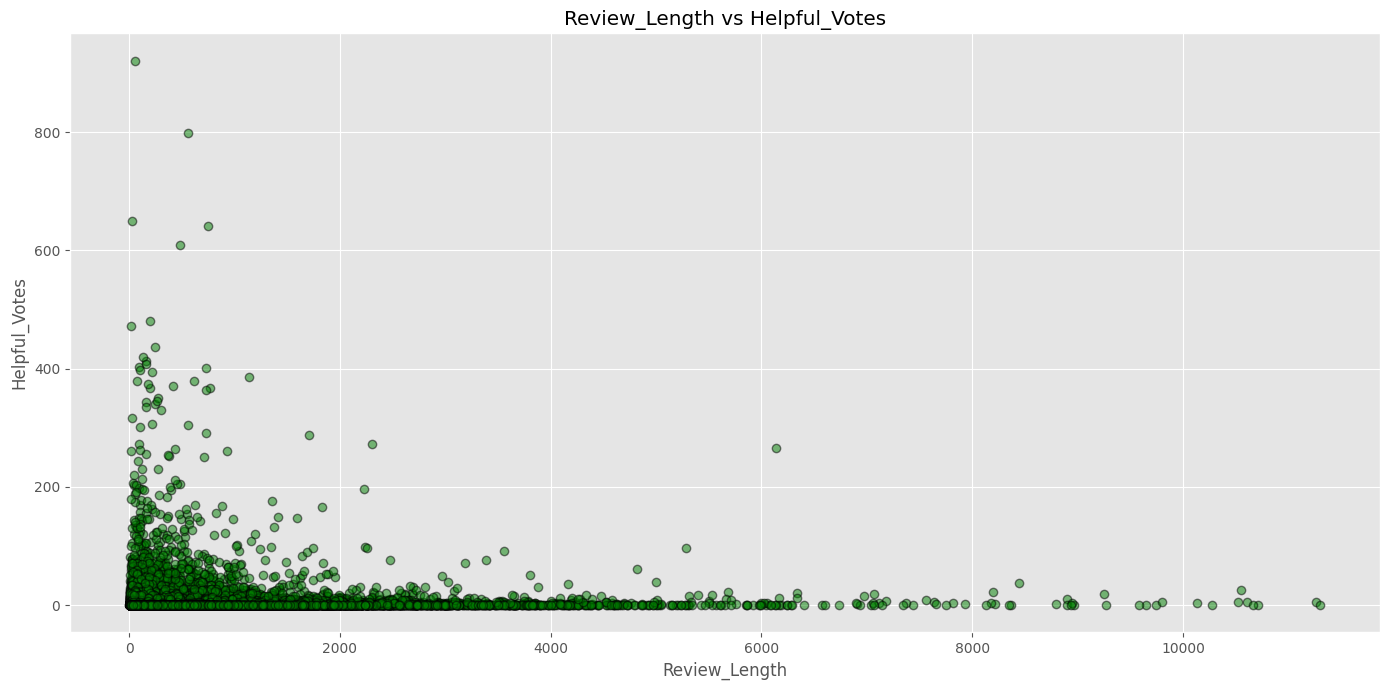

In [100]:
plt.style.use('ggplot')

plt.figure(figsize=(14, 7))

x = np.array(df['review_length'])
y = np.array(df['helpful_votes'])

plt.scatter(x, y, c='g', edgecolor='black', linewidth=1, alpha=0.5)

plt.title('Review_Length vs Helpful_Votes')
plt.xlabel('Review_Length')
plt.ylabel('Helpful_Votes')

plt.tight_layout()
plt.show()

In [101]:
# calculo de correlacion
correlation = df['review_length'].corr(df['helpful_votes'])
round(correlation, 2)

np.float64(-0.01)

Las reviews en el orden de los mil caracteres de largo o menos suelen ser las mas utiles

In [103]:
# estadisticas de longitud de reviews
df['review_length'].describe()

,review_length
count,24308.000000
mean,515.862802
std,786.123044
min,3.000000
25%,108.000000
50%,260.000000
75%,592.250000
max,11305.000000
